# Annotation population and spectral background of the 200-900 m/z window

This notebook characterizes the labelled population the `07_09_26_predictive_expanded`
campaign trains on, before any model exists: how many pixels and ions there are, how
often each ion is annotated, and what an ordinary spectrum looks like at the intensity
levels the evidence rule tests. It answers one question — *what is actually there to
label* — and deliberately answers no question about thresholds, which `part_0_2` does.

It is a precondition for `part_0_2` and `part_0_3`. Both select a threshold on the
relative intensity at an ion's bin, and a threshold is only interpretable against the
prevalence of the ions it applies to and the background level of the axis it sits on.

## Introduction

The campaign configuration `predictive_heads_initial.yaml` compares four families of
molecular head objective. Three of them — the P/N BCE, the P/N/U cross-entropy and,
indirectly, the class-balanced BCE — do not train on annotations alone. Annotations
give only positives; everything else is either an operational negative or an uncertain
entry, and which one it becomes is decided by
`SignalEvidencePolicy`: for a pixel $i$ and an ion $c$ it compares the local intensity
at the ion's bin against a fraction of the pixel's own maximum. Its parameters are
still `TODO` in the configuration.

Before that comparison can be calibrated, the population it runs over has to be
measured. Three properties decide how much work the rule has to do: how many ions are
annotated in how few pixels (rare classes), how much of the spectral axis carries
intensity at all (the background), and whether either varies systematically across the
fixed 200-900 m/z binning window.

### Assumptions

- **The population is the complete annotated image, not the training subset.** The
  campaign trains on a 10 % `proportional_multilabel` subset, but the evidence rule is
  a property of the data and of the binning, not of a training subsample. Measuring it
  on all 420 649 annotated pixels removes the subset draw as a source of variation. The
  consequence is that counts here are roughly ten times the counts a training run sees;
  shares and distributions transfer directly, absolute counts do not.
- **Absent annotation does not mean absent molecule.** METASPACE annotations are
  positive-only evidence at a fixed FDR. Every quantity called *prevalence* here is the
  prevalence of an *annotation*, never of a molecule. This is exactly why the campaign
  needs an evidence rule at all.
- **The spectra are the model inputs.** Everything is measured after the configured
  `LinearBinning` (0.55 Da, 200-900 m/z, sum aggregation) and TIC normalization, through
  the same `BatchPreprocessor` the trainer uses. Intensities are therefore shares of the
  pixel's total ion current, not raw counts.
- **Ion-to-bin mapping is taken as given here.** Whether an annotated m/z lands on the
  bin *carrying its peak* is a separate question, examined in `part_0_3`. How many ions
  land on the *same* bin is a property of the binning configuration alone and is
  reported below, because it bounds what any later per-ion statement can mean.

### Notation

- $i$ — one pixel (spectrum); $c$ — one ion target column, keyed `formula|adduct`.
- $x_i \in \mathbb{R}^{M}_{\ge 0}$ — the binned, TIC-normalized spectrum of pixel $i$,
  with $M = 1273$ bins and $\sum_b x_{ib} = 1$.
- $y_{ic} \in \{0, 1\}$ — the annotation indicator; $m_{ic}$ — label availability.
- $\mathcal{B}_c$ — the bins ion $c$ maps to.
- $\pi_c = \frac{\sum_i y_{ic} m_{ic}}{\sum_i m_{ic}}$ — annotation prevalence of ion $c$.
- $\rho$ — the `bin_radius` dilation; $\beta$ — the relative threshold; $\alpha$ — the
  absolute threshold. Neither $\beta$ nor $\alpha$ is selected in this notebook.

## Configuration

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.evidence import EvidenceStatistics
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import alignment_analysis as alignment
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import class_population_analysis as population
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import threshold_analysis as thresholds
from msi_autoencoder_wrapper.analysis.autoencoder.evidence import views
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("annotation_population")

2026-09-19 23:31:38,488 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-19 23:31:38,491 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


In [2]:
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/19_09_26_metaspace_heads_vpu_jaccard/analysis_settings.yaml")
settings = campaign.load_settings(SETTINGS_PATH)
EVIDENCE_CACHE = Path(settings["annotation_evidence_cache"])
ARTIFACT_DIR = SETTINGS_PATH.parent / "part_0_1_annotation_population_results"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# The campaign's own evidence parameters are used for its local annotation audit.
CONFIGURED_BIN_RADIUS = int(settings["evidence"]["bin_radius"])
CONFIGURED_THRESHOLDS = (float(settings["evidence"]["relative_threshold"]),)
BIN_STEP = 0.55

theme = resolve_theme(None)
theme.apply()

statistics = EvidenceStatistics.load(EVIDENCE_CACHE)
print(f"population: {statistics.spectrum_count} pixels x {statistics.class_count} ions")
print(f"source acquisitions: {len(statistics.group_names)}")
print(f"measured dilation radii: {statistics.bin_radii}")

2026-09-19 23:31:38,878 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-19 23:31:38,880 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-19 23:31:38,888 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-19 23:31:38,888 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 46 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-19 23:31:38,906 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-19 23:31:38,919 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-19 23:31:38,921 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 33 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


population: 420649 pixels x 508 ions
source acquisitions: 30
measured dilation radii: (0, 1, 2)


## Population and target geometry

### Methodology

#### Theoretical

Four counts fix the size of every later statement and the granularity at which any of
them can be trusted: the number of pixels carrying at least one annotation, the number
of ion target columns, the width $M$ of the spectral axis they are mapped onto, and the
number of source acquisitions the pixels come from. The last matters beyond
bookkeeping: the campaign's `proportional_multilabel` split groups by `dataset_id`, so
whole acquisitions move together between train, validation and test, and a property
that varies strongly by acquisition becomes a property that varies by split.

The mean number of annotated ions per pixel, $\overline{|\{c : y_{ic} = 1\}|}$, is the
quantity that determines how one-sided the label matrix is. With $C$ ion columns, each
pixel contributes $C$ entries to a multi-label objective and only that mean is
positive; everything else is what the evidence rule has to classify.

One further count is not bookkeeping but a hard limit on everything the evidence rule
can do. The map $c \mapsto \mathcal{B}_c$ is not injective at a 0.55 Da bin width:
isobaric ions, and ions whose exact masses differ by less than one bin, land on the same
coordinate. For any two such ions the rule reads *the same number*, so it necessarily
assigns them the same state in every pixel, and any per-ion evidence statistic computed
later is shared among them rather than measured independently. The number of ions in
that situation is therefore reported here, before any per-ion quantity is introduced.

#### Implementation

Read from the persisted population pass, which streamed every pixel once through the
campaign's own reader, binner and normalization. `spectrum_annotated_count` is the
per-pixel count of $y_{ic} = 1$ over available labels, and `spectrum_available_count`
the count of $m_{ic} = 1$; both were accumulated during the pass, not recomputed here.
The label policy configured for this campaign is `unobserved_label_policy: unlabelled`,
under which every ion column is available in every retained pixel, so the availability
count is expected to equal $C$ everywhere; it is reported rather than assumed.

Bin occupancy is counted by `bin_occupancy_records`, which groups the ion columns by the
centre of their mapped bin — the binner's own axis position, so the grouping reproduces
the mapping the dataset performed rather than re-deriving it from m/z.

#### Figure descriptions

Two tables. The first has one row per reported quantity with its value. The second lists
the most heavily shared bins: the bin centre, the number of ion columns mapped to it, and
their identities. No figure.

### Remarks

- The 508 ion columns occupy only 292 distinct bins; 328 of them share a bin with at
  least one other ion, and one bin carries 12. For those 328 columns the evidence rule
  cannot in principle distinguish which co-located ion a signal belongs to.
- Annotation load per pixel is extremely skewed: mean 25.0 against a median of 5, with a
  maximum of 227. The mean is not a usable summary here.

### Notes

In [3]:
available = statistics.spectrum_available_count
annotated = statistics.spectrum_annotated_count

geometry = pd.DataFrame([
    {"quantity": "pixels with annotations", "value": statistics.spectrum_count},
    {"quantity": "ion target columns (C)", "value": statistics.class_count},
    {"quantity": "spectral bins (M)", "value": int(statistics.metadata["feature_count"])},
    {"quantity": "source acquisitions", "value": len(statistics.group_names)},
    {"quantity": "available labels per pixel (min)", "value": int(available.min())},
    {"quantity": "available labels per pixel (max)", "value": int(available.max())},
    {"quantity": "annotated ions per pixel (mean)", "value": float(annotated.mean())},
    {"quantity": "annotated ions per pixel (median)", "value": float(np.median(annotated))},
    {"quantity": "annotated ions per pixel (min / max)", "value": f"{int(annotated.min())} / {int(annotated.max())}"},
    {"quantity": "share of (pixel, ion) entries that are annotated",
     "value": float(annotated.sum() / available.sum())},
    {"quantity": "ions mapping to more than one bin", "value": int((statistics.class_bin_counts > 1).sum())},
])

occupancy = pd.DataFrame(alignment.bin_occupancy_records(statistics))
occupancy.to_csv(ARTIFACT_DIR / "bin_occupancy.csv", index=False)
shared = occupancy[occupancy["ions"] > 1]
geometry = pd.concat([geometry, pd.DataFrame([
    {"quantity": "distinct bins occupied by the 508 ions", "value": len(occupancy)},
    {"quantity": "bins carrying more than one ion", "value": len(shared)},
    {"quantity": "ions sharing a bin with another ion", "value": int(shared["ions"].sum())},
    {"quantity": "ions in the most crowded bin", "value": int(occupancy["ions"].max())},
])], ignore_index=True)
display(geometry)
geometry.to_csv(ARTIFACT_DIR / "population_geometry.csv", index=False)
display(occupancy.head(5))

2026-09-19 23:31:39,169 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.alignment_analysis:170 | Bin occupancy: 328 ion(s) share a bin with at least one other over 292 occupied bin(s).


,quantity,value
0,pixels with annotations,420649
1,ion target columns (C),508
2,spectral bins (M),1273
3,source acquisitions,30
4,available labels per pixel (min),508
5,available labels per pixel (max),508
6,annotated ions per pixel (mean),24.951339
7,annotated ions per pixel (median),5.0
8,annotated ions per pixel (min / max),1 / 227
9,"share of (pixel, ion) entries that are annotated",0.049117


,bin_centre,ions,class_names
0,325.125702,12,C13H18N4O6|-H|C14H30N2O4|+Cl|C14H30O8|-H|C16H2...
1,265.175354,11,C10H19O6P|-H|C10H9Cl3O2|-H|C12H26O4S|-H|C15H14...
2,311.375610,10,C12H21N7O3|[M]-|C15H20O7|-H|C17H16N2O4|-H|C17H...
3,353.175842,9,C15H31O7P|-H|C20H18O6|-H|C20H26N4O2|-H|C21H38O...
4,215.125092,8,C11H20O4|-H|C12H24O3|-H|C12H8O4|-H|C5H13O7P|-H...


## Spectral background above a relative intensity level

### Methodology

#### Theoretical

The evidence rule declares an entry negative when the intensity at its bin does not
exceed a fraction $\beta$ of the pixel's own maximum. Whether that is a meaningful test
depends entirely on what an *arbitrary* bin looks like at that level. Define, over every
pixel and every bin,

$$
G(\beta) \;=\; \Pr\!\left(\frac{x_{ib}}{\max_{b'} x_{ib'}} > \beta\right),
\qquad
N(\beta) \;=\; M \cdot G(\beta),
$$

so $N(\beta)$ is the expected number of bins of one spectrum above the level $\beta$.
This is the null model the per-ion evidence must be read against, and it bounds the rule
from both sides. If $N(\beta) \approx M$, the threshold sits under the noise floor and
almost nothing can fall below it, so the rule produces almost no negatives. If
$N(\beta) \approx 0$, the threshold sits above nearly every real peak, so the rule
declares almost everything negative regardless of chemistry. A usable threshold lies
where $N(\beta)$ is comparable to the number of genuine peaks in a spectrum.

#### Implementation

Accumulated during the population pass as a histogram over $x_{ib} / \max_{b'} x_{ib'}$
taken over all $420\,649 \times 1273$ bin values, on a logarithmic grid of 40 boundaries
per decade spanning $10^{-6}$ to $1$, with the campaign's candidate thresholds inserted
as exact boundaries. $G(\beta)$ is one minus the cumulative count at the boundary
$\beta$, so it is an exact count at every plotted point rather than an interpolation.
Bins with exactly zero intensity occupy a dedicated bucket, since a logarithmic axis
cannot represent them.

#### Figure descriptions

The x-axis is the relative intensity level $\beta$ on a logarithmic scale; the y-axis is
$N(\beta)$, the expected number of bins of one spectrum above that level, also
logarithmic. The single grey curve is measured over every bin of every pixel and
describes the spectral axis itself, not any ion. The dotted vertical lines mark the two
relative thresholds the campaign currently proposes. Reading the curve at those lines
gives, directly, how many bins of an ordinary spectrum sit above the proposed
thresholds; a value close to the full 1273 bins means the threshold separates nothing.

### Remarks

### Notes

,relative_threshold,bins_at_or_below_fraction,bins_above_fraction,bins_above_per_spectrum
0,0.0000,0.492585,0.507415,645.939455
168,0.0119,0.694860,0.305140,388.443296


bins with exactly zero intensity: 49.258% of all (pixel, bin) entries


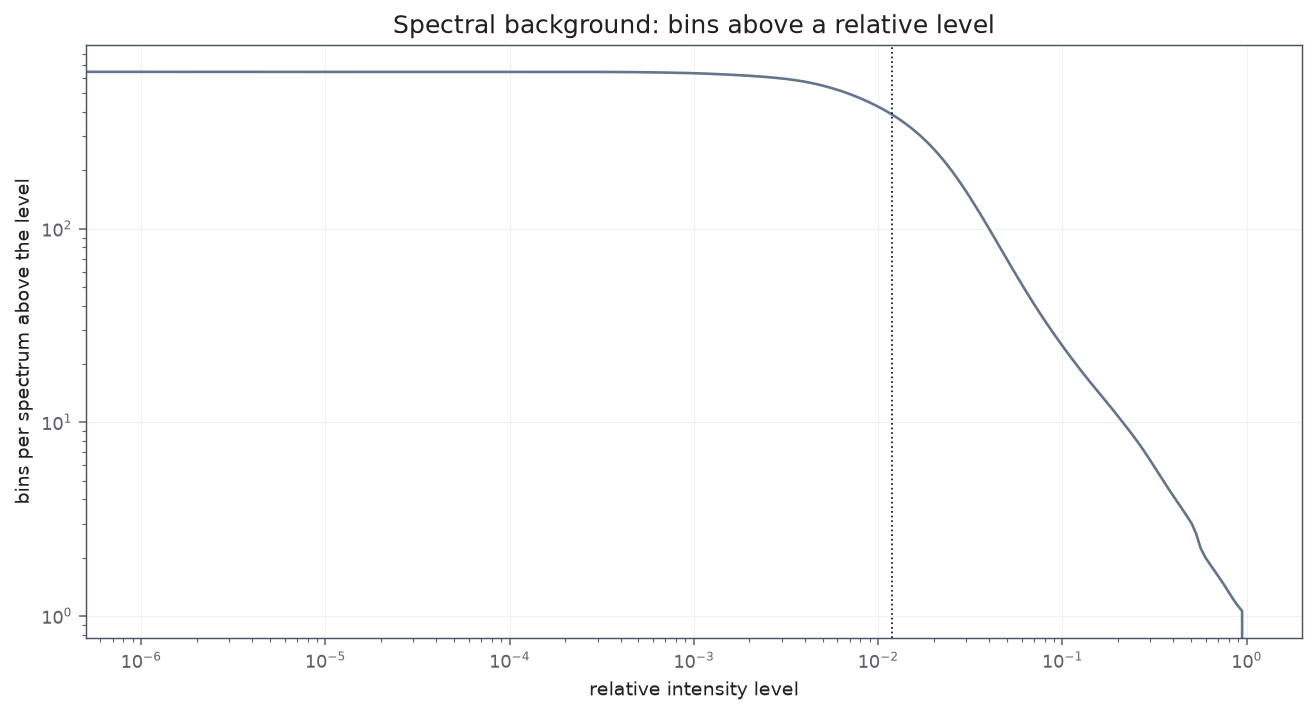

In [4]:
background = pd.DataFrame(thresholds.background_exceedance_records(statistics))
background.to_csv(ARTIFACT_DIR / "background_exceedance.csv", index=False)

figure, axis = plt.subplots(figsize=(9.5, 5.2), dpi=theme.figure_dpi)
views.plot_background_exceedance(
    background.to_dict("records"), candidate_thresholds=CONFIGURED_THRESHOLDS, ax=axis, theme=theme
)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "background_exceedance.png")

marked = background[background["relative_threshold"].isin([0.0, *CONFIGURED_THRESHOLDS])]
display(marked.round(6))
zero_share = statistics.background_relative[0] / statistics.background_relative.sum()
print(f"bins with exactly zero intensity: {zero_share:.3%} of all (pixel, bin) entries")

## Per-ion annotation prevalence

### Methodology

#### Theoretical

The prevalence $\pi_c$ of ion $c$ is the share of pixels with an available label in
which the ion is annotated. It is fixed by the annotations alone: no evidence rule and
no threshold enters it. Two consequences follow for the campaign. A class with a very
small $\pi_c$ contributes almost no positive gradient to any objective, so its
prediction quality is dominated by how the objective treats its negatives — which is
precisely what the P/N and P/N/U variants change. And because the prevalence
distribution across ions is what the class-balancing options
(`train_inverse_prevalence`, `per_class_sqrt_negative_to_positive`) are computed from,
its shape determines how aggressively those options reweight.

#### Implementation

Counted from the population pass: per ion, the number of entries in the annotated
histogram against the total over both histograms. Ordering for the curve is by
prevalence, descending; the ordering is presentational and carries no other meaning.

#### Figure descriptions

The x-axis is the ion's rank by prevalence, from most to least prevalent; the y-axis is
its prevalence on a logarithmic scale. Each point is one ion, and the curve connects
them in rank order only — neighbouring points are not chemically related. A curve that
falls steeply and then flattens into a long tail means most ion columns are annotated in
a negligible share of pixels; the height of the tail is the prevalence a pooled
per-class metric would be dominated by.

### Remarks

- Median prevalence is 1.9 %; 198 of 508 ions are annotated in under 1 % of pixels and
  388 in under 5 %. Any per-class metric averaged over ion columns is therefore
  dominated by classes that are almost never positive.

### Notes

2026-09-19 23:31:40,075 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.evidence.class_population_analysis:60 | Summarized annotation prevalence for 508 ion(s).


,0.00,0.05,0.25,0.50,0.75,0.95,1.00
prevalence,0.00002,0.00019,0.00324,0.01918,0.04755,0.19463,0.32157


ions annotated in fewer than 0.1% of pixels: 75/508 (14.8%)
ions annotated in fewer than 1.0% of pixels: 198/508 (39.0%)
ions annotated in fewer than 5.0% of pixels: 388/508 (76.4%)
ions annotated in fewer than 10.0% of pixels: 415/508 (81.7%)


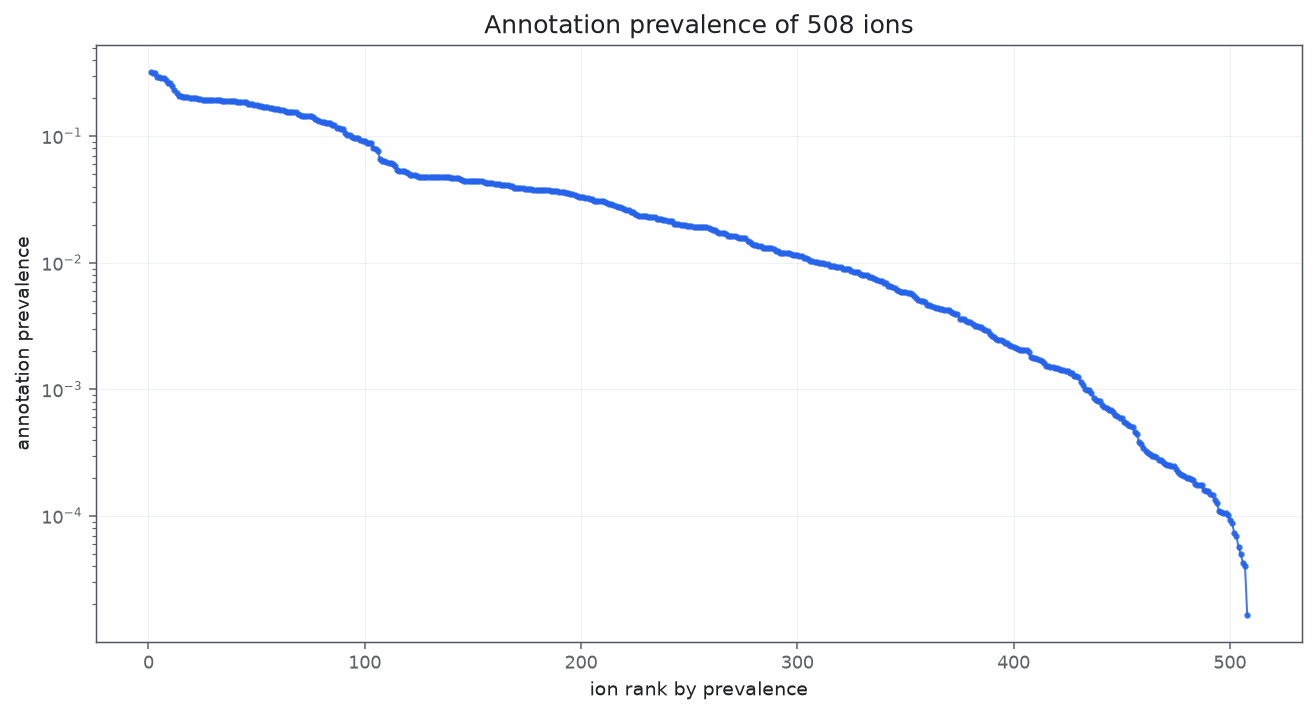

In [5]:
prevalence = pd.DataFrame(population.class_prevalence_records(statistics))
prevalence.to_csv(ARTIFACT_DIR / "class_prevalence.csv", index=False)

figure, axis = plt.subplots(figsize=(9.5, 5.2), dpi=theme.figure_dpi)
views.plot_prevalence_curve(prevalence.to_dict("records"), ax=axis, theme=theme)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "class_prevalence.png")

quantiles = prevalence["prevalence"].quantile([0.0, 0.05, 0.25, 0.5, 0.75, 0.95, 1.0])
display(quantiles.rename("prevalence").to_frame().T.round(5))
for cut in (0.001, 0.01, 0.05, 0.10):
    share = float((prevalence["prevalence"] < cut).mean())
    print(f"ions annotated in fewer than {cut:.1%} of pixels: {int(share * len(prevalence))}/{len(prevalence)} ({share:.1%})")

## Annotation density and detectability across the m/z window

### Methodology

#### Theoretical

The binning window is fixed at 200-900 m/z by configuration, and there is no reason for
annotation density to be uniform across it: lipid classes occupy characteristic mass
ranges, and instrument sensitivity varies with m/z. Two quantities are aggregated in
50 Da windows: the mean annotation prevalence of the ions falling in the window, and the
share of their unannotated entries that would fall below a reference threshold. The
second is *not* a threshold selection — it is fixed at the campaign's current lower
candidate purely to expose where in the window the axis is empty. A region where
prevalence is low *and* the negative share is near one contributes label mass that
carries no chemical contrast, only the absence of measurement.

#### Implementation

Ions are placed by their annotated m/z, falling back to the centre of their mapped bin
where the reader exposes no m/z. Windows are 50 Da wide, spanning the observed range;
windows containing no ion are omitted rather than plotted as zero. Both quantities are
entry-weighted within the window, so an ion annotated in many pixels contributes
proportionally more than one annotated in few.

#### Figure descriptions

The x-axis is m/z across the configured window. The blue step curve, on the left axis,
is the mean annotation prevalence of the ions inside each 50 Da window. The red dashed
step curve, on the right axis, is the share of those ions' unannotated entries whose
relative evidence lies at or below the reference threshold of 0.005 — the share that
would become operational negatives at that value. Two axes are used because the
quantities have unrelated scales. Regions where the blue curve is low and the red curve
is near one are parts of the mass axis that are both rarely annotated and essentially
empty.

### Remarks

- The negative share varies by a factor of four across the window, from 0.15 in
  300-350 m/z to 0.59 in 600-650 m/z, so the rule's effect is strongly m/z-dependent.
- Annotation density is bimodal: dense below 400 m/z and again in 700-900 m/z, sparse in
  between (6 ions in 650-700 m/z, 11 in 450-500 m/z).

### Notes

,mz_lower,mz_upper,ions,bin_radius,relative_threshold,annotated_entries,mean_prevalence,negative_fraction_of_unannotated
0,200.0,250.0,48,1,0.0119,676158.0,0.0335,0.4298
1,250.0,300.0,60,1,0.0119,1188130.0,0.0471,0.3800
2,300.0,350.0,83,1,0.0119,1414820.0,0.0405,0.2551
3,350.0,400.0,57,1,0.0119,563844.0,0.0235,0.4766
4,400.0,450.0,33,1,0.0119,462353.0,0.0333,0.4459
5,450.0,500.0,11,1,0.0119,243118.0,0.0525,0.4468
6,500.0,550.0,20,1,0.0119,341243.0,0.0406,0.5309
7,550.0,600.0,13,1,0.0119,205269.0,0.0375,0.6168
8,600.0,650.0,12,1,0.0119,176663.0,0.0350,0.6445
9,650.0,700.0,6,1,0.0119,337517.0,0.1337,0.6958


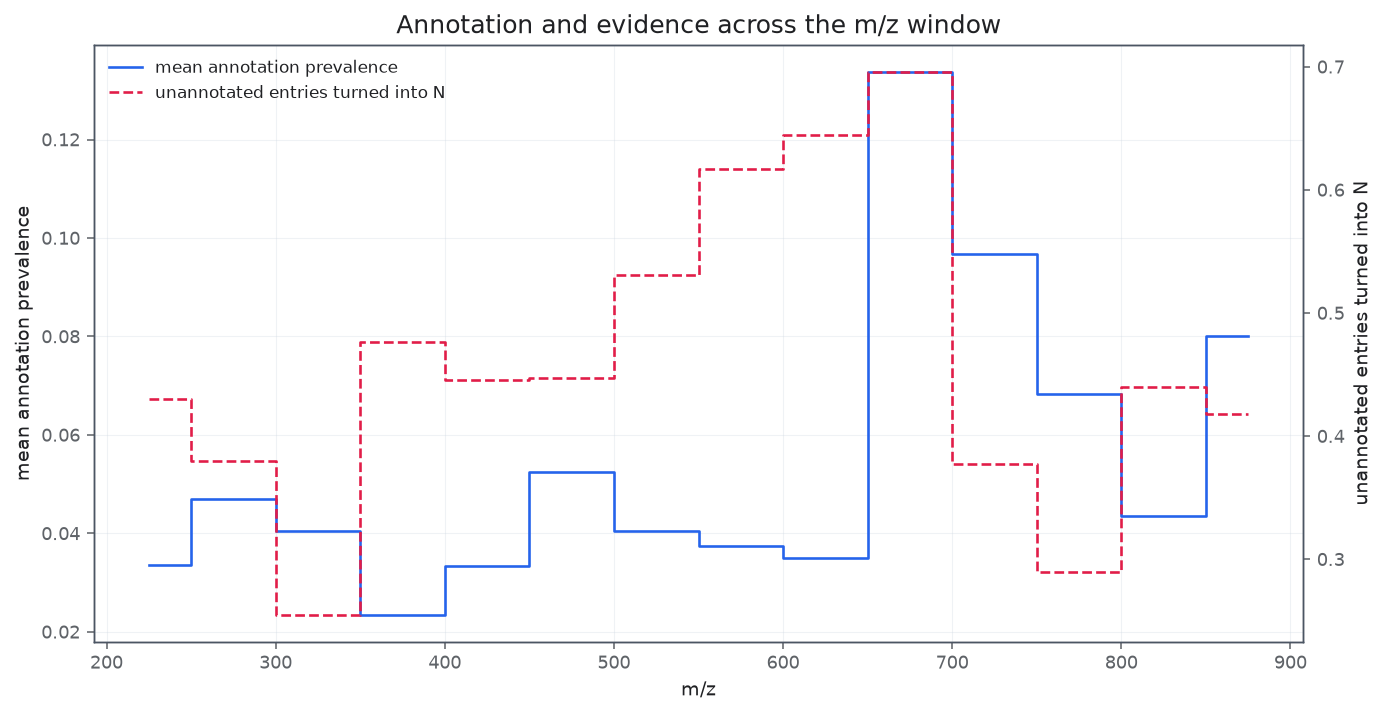

In [6]:
mz_windows = pd.DataFrame(population.mz_window_records(
    statistics, bin_radius=CONFIGURED_BIN_RADIUS, relative_threshold=CONFIGURED_THRESHOLDS[0], window_width=50.0
))
mz_windows.to_csv(ARTIFACT_DIR / "mz_windows.csv", index=False)

figure, axis = plt.subplots(figsize=(10.0, 5.2), dpi=theme.figure_dpi)
views.plot_mz_profile(mz_windows.to_dict("records"), ax=axis, theme=theme)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "mz_profile.png")

display(mz_windows.round(4))

## Per-pixel annotation load across source acquisitions

### Methodology

#### Theoretical

A batch of any multi-label objective is a set of pixels, and what it contains is decided
by how many ions each pixel carries. If the number of annotated ions per pixel varies
strongly between acquisitions, then, because the split assigns whole acquisitions, the
train and evaluation partitions differ in label density before any modelling decision is
made — and a metric computed per class would be measuring partly which acquisitions
landed where. The distribution is therefore reported per acquisition and in full, not as
a single mean.

#### Implementation

Per-pixel annotated counts from the population pass, grouped by the `dataset_id`
metadata field resolved through the annotation reader — the same field the campaign's
split uses as `group_fields`. Acquisitions are ordered by median annotated count. The
violin uses every pixel of the acquisition; the overlaid points are a deterministic
subsample of at most 200 pixels per acquisition, drawn with a fixed seed, because
several acquisitions hold tens of thousands of pixels and an exhaustive overlay would be
solid ink.

#### Figure descriptions

The x-axis lists the source acquisitions, ordered by their median annotated-ion count;
the y-axis is the number of annotated ions in one pixel, out of the 508 ion columns.
Each violin is the complete distribution over that acquisition's pixels; the points
overlaid on it are the fixed-seed subsample described above and must not be read as the
complete sample. Vertical spread within one violin is biological and spatial variation
inside one acquisition; displacement between violins is between-acquisition variation,
which is what propagates into the split.

### Remarks

- Median annotation load spans two orders of magnitude across acquisitions, from 1 to 79
  annotated ions per pixel. The three richest acquisitions (medians 61, 75 and 79) hold
  124 724 of 420 649 pixels, so the split's composition largely decides what a partition
  looks like.
- Median nonzero bin count is stable near 250 across acquisitions while the annotation
  load is not, so the difference is in annotation coverage rather than in spectral
  quality.

### Notes

,group,pixels,median_annotated,mean_annotated,min_annotated,max_annotated,median_nonzero_bins,median_spectrum_maximum
0,2024-02-19_05h02m33s,8033,1.0,1.4987,1,4,249.0,0.0838
1,2024-02-19_05h42m55s,10971,2.0,2.1701,1,6,248.0,0.1004
2,2024-02-19_05h12m47s,6497,3.0,3.3188,1,6,258.0,0.0827
3,2024-02-20_01h41m56s,12026,3.0,2.7853,1,5,250.0,0.1153
4,2024-02-20_01h45m20s,10978,3.0,3.1545,1,6,252.0,0.1140
5,2024-02-20_01h46m10s,8833,3.0,3.0158,1,6,250.0,0.1255
6,2024-02-20_01h49m35s,8273,3.0,3.7072,1,9,251.0,0.0950
7,2024-02-20_01h38m59s,11431,4.0,3.5111,1,7,253.0,0.1123
8,2024-02-20_01h44m07s,10043,4.0,3.5168,1,7,253.0,0.1056
9,2024-02-20_01h43m24s,10601,4.0,3.3682,1,6,255.0,0.1049


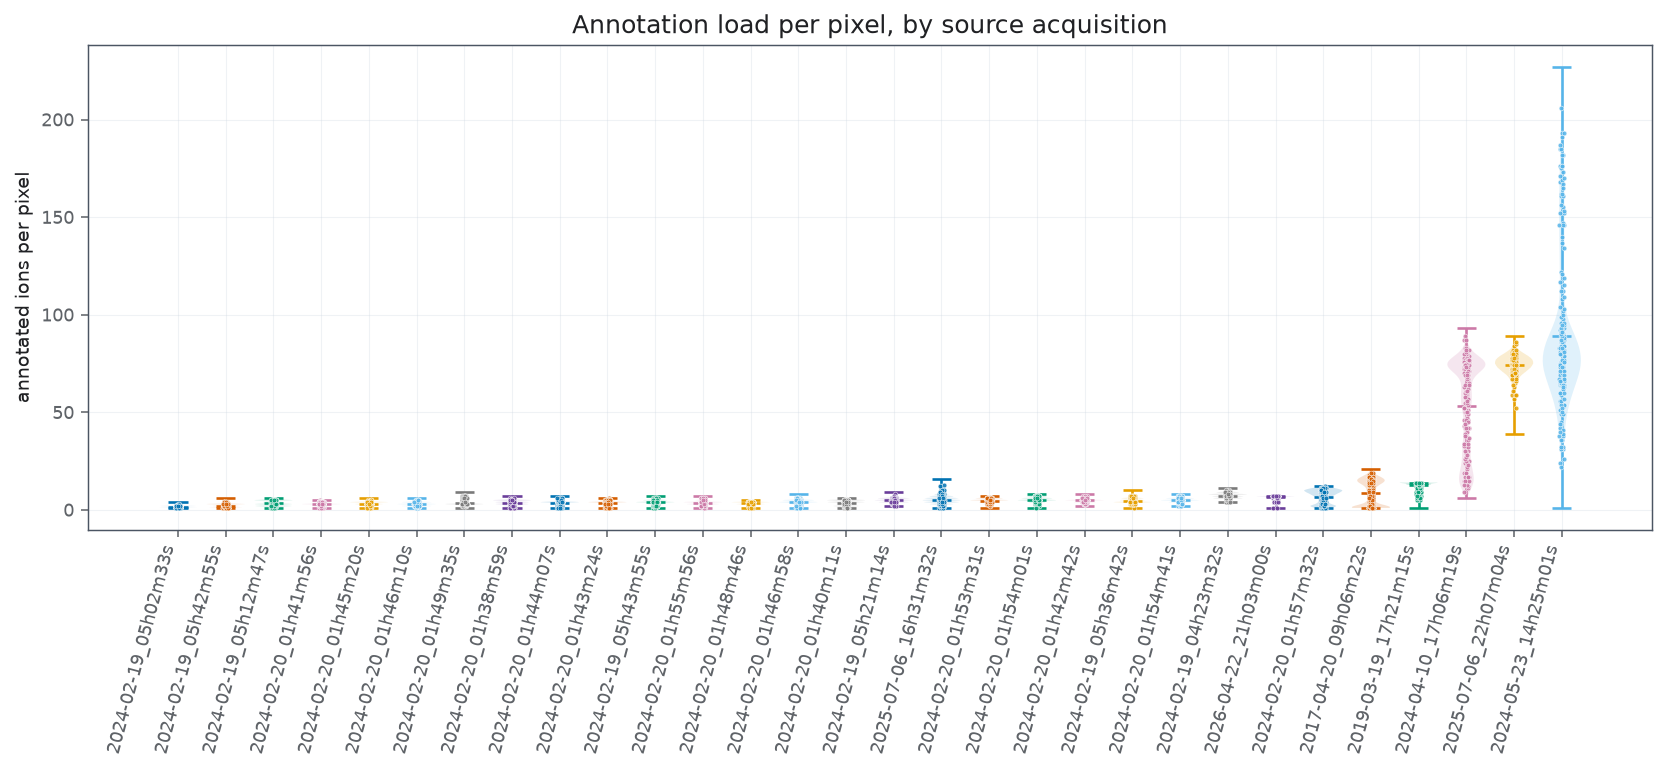

In [7]:
pixel_frame = pd.DataFrame({
    "spectrum_id": statistics.spectrum_ids,
    "group": [statistics.group_names[index] for index in statistics.spectrum_group_index],
    "annotated_ions": statistics.spectrum_annotated_count,
    "spectrum_maximum": statistics.spectrum_maximum,
    "nonzero_bins": statistics.spectrum_nonzero_bins,
})
pixel_summary = (
    pixel_frame.groupby("group")
    .agg(pixels=("spectrum_id", "size"),
         median_annotated=("annotated_ions", "median"),
         mean_annotated=("annotated_ions", "mean"),
         min_annotated=("annotated_ions", "min"),
         max_annotated=("annotated_ions", "max"),
         median_nonzero_bins=("nonzero_bins", "median"),
         median_spectrum_maximum=("spectrum_maximum", "median"))
    .sort_values("median_annotated")
    .reset_index()
)
pixel_summary.to_csv(ARTIFACT_DIR / "acquisition_summary.csv", index=False)
display(pixel_summary.round(4))

OVERLAY_SEED = 20260907
OVERLAY_POINTS = 200
generator = np.random.default_rng(OVERLAY_SEED)

figure, axis = plt.subplots(figsize=(12.0, 5.6), dpi=theme.figure_dpi)
for position, group in enumerate(pixel_summary["group"]):
    values = pixel_frame.loc[pixel_frame["group"] == group, "annotated_ions"].to_numpy()
    overlay = values if values.size <= OVERLAY_POINTS else generator.choice(values, OVERLAY_POINTS, replace=False)
    plot_violin_with_points(values, position=position, ax=axis, width=0.8,
                            color=theme.color_for_model(group, position), theme=theme,
                            overlay_values=overlay, point_size=6.0)
axis.set_xticks(range(len(pixel_summary)))
axis.set_xticklabels(pixel_summary["group"], rotation=75, ha="right")
axis.set(ylabel="annotated ions per pixel", title="Annotation load per pixel, by source acquisition")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()
figure.savefig(ARTIFACT_DIR / "acquisition_annotation_load.png")

## Results / Summary

### LLM

**Population.** 420 649 annotated pixels, 508 ion columns, 1273 bins, 30 source
acquisitions. Every ion column is available in every pixel, as the configured
`unobserved_label_policy: unlabelled` requires. 4.91 % of all (pixel, ion) entries are
annotated; the other 95.09 % are what the evidence rule has to classify.

**Observed results, in decreasing order of consequence for the campaign.**

1. *The ion targets are not separable on the spectral axis.* The 508 columns occupy 292
   distinct bins; 328 columns (64.6 %) share a bin with at least one other, and the most
   crowded bin carries 12. Since the evidence rule reads one number per bin, those 328
   columns receive identical evidence by construction. This is a consequence of the
   0.55 Da binning, not of the rule, and it is a hard ceiling on what any threshold can
   resolve. It also means per-ion evidence statistics in `part_0_2` are shared within a
   bin rather than independent measurements — an interpretation limit, not an error.
2. *Both proposed thresholds sit inside the populated part of the spectral axis.* At
   $\beta = 0.005$, 548 of 1273 bins per spectrum are still above the threshold; at
   $\beta = 0.01$, 427. Combined with the 49.3 % of bin entries that are exactly zero,
   the thresholds cut through the body of the intensity distribution rather than under
   it. Whether that is right is decided in `part_0_2`; what is established here is that
   it is a substantive cut, not a formality.
3. *Annotation load per pixel is extremely uneven between acquisitions* — medians from 1
   to 79 annotated ions, a two-order-of-magnitude spread, while the median nonzero bin
   count stays near 250 everywhere. The difference is annotation coverage, not spectral
   quality. Because the campaign's split groups by `dataset_id`, this variation is
   inherited directly by the train/validation/test partitions; `part_0_3` measures what
   it does to the evidence rule.
4. *Prevalence is low and heavy-tailed*: median 1.9 %, with 198 of 508 ions annotated in
   under 1 % of pixels. Any metric averaged over ion columns is dominated by classes that
   are almost never positive, which is directly relevant to the campaign's
   `balanced_class_mean` reduction and its per-class weighting options.
5. *The rule's effect is m/z-dependent*: the share of unannotated entries below the
   reference threshold ranges from 0.15 (300-350 m/z) to 0.59 (600-650 m/z).

**Interpretation and limits.** Findings 1 and 3 are structural properties of the
configuration and the cohort and hold regardless of any threshold choice. Findings 2 and
5 are measurements at a reference threshold and are inputs to, not conclusions of, the
selection in `part_0_2`. Nothing here is evidence about which head objective performs
better; the whole notebook is prior to training. Counts are on the complete annotated
image and are about ten times what a training run on the configured 10 % subset sees;
shares transfer, absolute counts do not.

### Person